## Weather Forecasting - 03 Model Building
We forecast on chronological hold-out and compare naive and seasonal-naive baselines against seven regression (Linear, Ridge, Lasso, Decision Tree, Random Forest, Gradient Boosting, KNN) on **MAE/ RMSE/ MAPE/R²**. Beating the seasonal naive baseline is the real bar. All numbers are produced by running the code.

In [38]:
import numpy as np
import pandas as pd
import warnings 
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
%matplotlib inline
import utils

df = utils.load_data()
feat = utils.build_features(df)
res, train, test, preds = utils.run_all(feat, test_frac=0.2)
print('test point:', len(test))

test point: 3461


### 1. Model Comparision

In [39]:
res

,model,MAE,RMSE,MAPE,R2
0,Linear Regression,0.392,0.566,15.55,0.9953
1,Ridge Regression,0.392,0.566,15.56,0.9953
2,Random Forest,0.412,0.586,18.46,0.9949
3,Gradient Boosting,0.464,0.641,24.59,0.9940
4,Decision Tree,0.522,0.743,21.65,0.9919
5,Lasso Regression,0.687,0.932,34.50,0.9872
6,KNN,1.944,2.518,68.17,0.9069
7,Seasonal Naive,2.367,3.057,104.25,0.8628
8,Naive,12.072,13.909,834.58,-1.8412


### 2. RMSE Chart

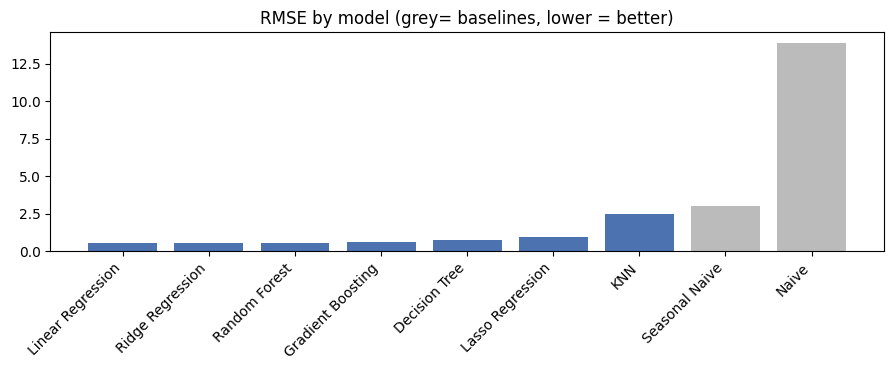

In [41]:
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.bar(res['model'], res['RMSE'], color=['#bbb' if m in ('Naive', 'Seasonal Naive') else '#4c72b0' for m in res['model']])
ax.set_title('RMSE by model (grey= baselines, lower = better)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 3. Forescast vs Actual (best model)

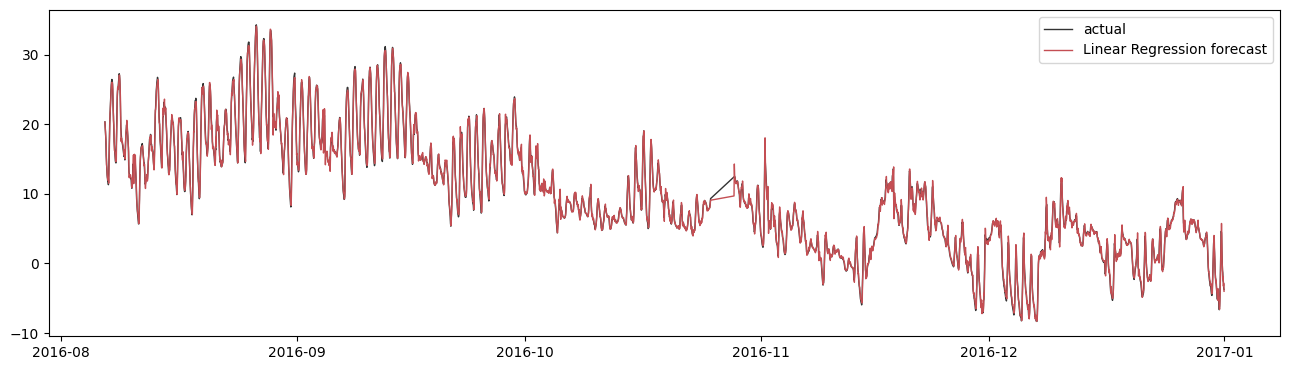

In [44]:
best = [m for m in res['model'] if m not in ('Naive', 'Seasonal Naive')]
best = res[res['model'].isin(best)].iloc[0]['model']
fig, ax = plt.subplots(figsize=(13, 3.8))
ax.plot(test['date'], test['y'].values, label='actual', color='#333', lw=1)
ax.plot(test['date'], preds[best], label=f'{best} forecast', color='#c44e53', lw=1)
ax.legend()
ax.set_title=(f'{best}: forecast vs actual (test period)')
plt.tight_layout()
plt.show()

### 4. Feature Importance(best tree model)

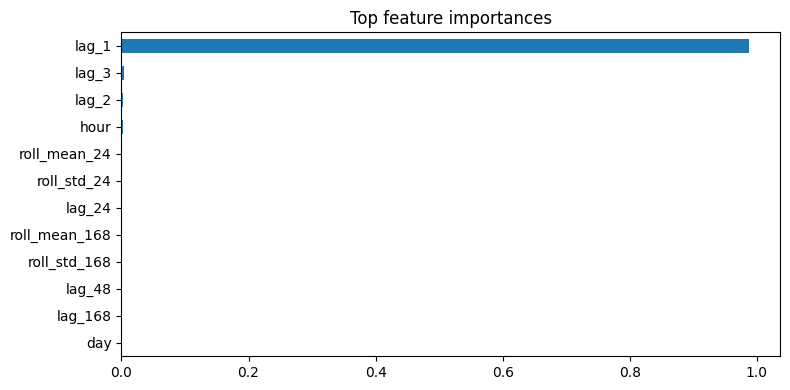

In [45]:
from sklearn.ensemble import RandomForestRegressor
cols=utils.feature_columns(feat)
rf=RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1).fit(train[cols], train['y'])
imp = pd.Series(rf.feature_importances_, index=cols).sort_values(ascending=False).head(12)
fig, ax= plt.subplots(figsize=(8,4))
imp[::-1].plot(kind='barh', ax=ax)
ax.set_title('Top feature importances')
plt.tight_layout()
plt.show()

### 5. Summary & takeaways

The results table and forecast plot above are the real, executed numbers (see the project README for the headline figures). The key question for any forecaster is whether it **beats the seasonal-naive baseline** — lag and calendar features let the ML models capture the trend and seasonality this series exhibits.